# Machine Learning Foundations - Data Preparation

Intro...

## Task ordering

1. Data Loading
2. Prediction Target and Feature Exploration
3. Visualizing features against target
4. Data Splitting
5. Managing Missing Values
6. Encoding Categorical Variables
7. Feature Scaling
8. Addressing Class Imbalance
9. Feature Selection
10. Training a Logistic Regression Model
11. Model Evaluation

## 1. Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import grid

In [2]:
df = pd.read_csv('bank-additional.csv', sep=';')

pd.set_option('display.max_columns', None)
print(df.head())

   age          job  marital          education default  housing     loan  \
0   30  blue-collar  married           basic.9y      no      yes       no   
1   39     services   single        high.school      no       no       no   
2   25     services  married        high.school      no      yes       no   
3   38     services  married           basic.9y      no  unknown  unknown   
4   47       admin.  married  university.degree      no      yes       no   

     contact month day_of_week  duration  campaign  pdays  previous  \
0   cellular   may         fri       487         2    999         0   
1  telephone   may         fri       346         4    999         0   
2  telephone   jun         wed       227         1    999         0   
3  telephone   jun         fri        17         3    999         0   
4   cellular   nov         mon        58         1    999         0   

      poutcome  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
0  nonexistent          -1.8        

In [3]:
print('Number of Rows:', df.shape[0])
print('Number of Features:', df.shape[1])
print(df.dtypes)

Number of Rows: 4119
Number of Features: 21
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object


## 2. Prediction Target and Feature Exploration

### Description of features

| Feature            | Description                                  | Data Type   |
|--------------------|----------------------------------------------|-------------|
| **age**            | Customer age                                 | Integer     |
| **job**            | Type of job                                  | Categorical |
| **marital**        | Marital status                               | Categorical |
| **education**      | Education level                              | Categorical |
| **default**        | Credit in default                            | Categorical |
| **housing**        | Housing loan                                 | Categorical |
| **loan**           | Personal loan                                | Categorical |
| **contact**        | Contact type                                 | Categorical |
| **month**          | Month of contact                             | Categorical |
| **day_of_week**    | Day of contact                               | Categorical |
| **duration**       | Call duration                                | Integer     |
| **campaign**       | Number of contacts performed during campaign | Integer     |
| **pdays**          | Number of days since last contact            | Integer     |
| **previous**       | Number of previous contacts                  | Integer     |
| **poutcome**       | Outcome of previous campaing                 | Categorical |
| **emp.var.rate**   | Employment variation rate                    | Float       |
| **cons.price.idx** | Consumer price index                         | Float       |
| **cons.conf.idx**  | Consumer confidence index                    | Float       |
| **euribor3m**      | Euribor 3-month rate                         | Float       |
| **nr.employed**    | Number of employees                          | Float       |
| **y**              | Client subscribed to term investment         | Binary      |

Identify column y as target

Subscribed to term deposit after call

Justify why this column represents the appropriate prediction objective in the context of the marketing
campaign.

Identify at least two other variables that could superficially appear to be valid targets and explain why they
should not be treated as the prediction objective:
- A. duration
- B. poutcome (previous campaign outcome)

Analyze the distribution of the target variable and comment on potential class imbalance

Change y to numerical for easier understanding and calculations

In [4]:
df['y'] = df['y'].replace({'no': 0, 'yes': 1})

print(df['y'].value_counts())

y
0    3668
1     451
Name: count, dtype: int64


In [5]:
print(df['y'].value_counts(normalize=True)*100)

y
0    89.05074
1    10.94926
Name: proportion, dtype: float64


10.95% of call success for the company

This indicates significant class imbalance.

The dataset is heavily skewed toward non-subscription.

Consequences:

A naïve model predicting "no" always would achieve ~89% accuracy. (Baseline)

Accuracy alone is not an appropriate metric.

Precision, recall, F1-score, and ROC-AUC are more informative.

### Numerical feature statistics

In [6]:
print(df.describe())

               age     duration     campaign        pdays     previous  \
count  4119.000000  4119.000000  4119.000000  4119.000000  4119.000000   
mean     40.113620   256.788055     2.537266   960.422190     0.190337   
std      10.313362   254.703736     2.568159   191.922786     0.541788   
min      18.000000     0.000000     1.000000     0.000000     0.000000   
25%      32.000000   103.000000     1.000000   999.000000     0.000000   
50%      38.000000   181.000000     2.000000   999.000000     0.000000   
75%      47.000000   317.000000     3.000000   999.000000     0.000000   
max      88.000000  3643.000000    35.000000   999.000000     6.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx    euribor3m  nr.employed  
count   4119.000000     4119.000000    4119.000000  4119.000000  4119.000000  
mean       0.084972       93.579704     -40.499102     3.621356  5166.481695  
std        1.563114        0.579349       4.594578     1.733591    73.667904  
min       -3.4000

### Unknowns

#### Categorical

In [7]:
unknowns = pd.DataFrame({
    'unknown count': (df == 'unknown').sum(),
    'unknown %': (df == 'unknown').mean() * 100
})

unknowns = unknowns[unknowns['unknown count'] > 0]

unknowns = unknowns.sort_values(
    by='unknown %',
    ascending=False
)

unknowns

,unknown count,unknown %
default,803,19.495023
education,167,4.054382
housing,105,2.549162
loan,105,2.549162
job,39,0.946832
marital,11,0.267055


default has the greatest amount of missing data

poutcome has 85.5% nonexistent but that is intentional

#### Numerical

In [8]:
df['pdays'].value_counts()

pdays
999    3959
3        52
6        42
4        14
7        10
10        8
12        5
5         4
2         4
1         3
9         3
18        2
15        2
0         2
16        2
13        2
11        1
19        1
17        1
21        1
14        1
Name: count, dtype: int64

pdays has most records as 999, the rest are between 1 and 21, which make a small portion of the dataset

In [9]:
print(df.groupby('pdays')['y'].mean())
print(f'\nAverage positive y without 999: {df.groupby('pdays')['y'].mean().drop(999).mean() * 100:.2f}%')
print(f'\nAverage positive y of 999: {df.groupby('pdays')['y'].mean()[999] * 100:.2f}%')

pdays
0           1.0
1           0.0
2          0.25
3          0.75
4      0.357143
5           1.0
6      0.642857
7           0.8
9      0.333333
10         0.75
11          0.0
12          0.6
13          0.0
14          0.0
15          0.5
16          0.0
17          0.0
18          0.5
19          1.0
21          1.0
999    0.088659
Name: y, dtype: object

Average positive y without 999: 47.42%

Average positive y of 999: 8.87%


From the table of pdays to y, the average proportion of true y when previously contacted (no matter amount of days) is 47.42%.

While the average proportion of true y when NOT previously contacted is 8.87%


This difference in positive y means that as long as the customer is contacted previously, no matter the amount of days it is more likely that they subscribe to the term deposit. The model will work better with a simplified binary representation of pdays, 1 previously contacted and 0 not contacted.

## 3. Visualizing features

### Age

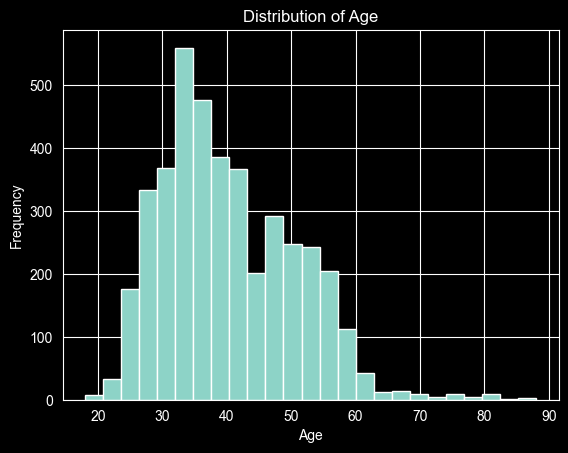

In [10]:
plt.figure()
plt.hist(df['age'], bins=25)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

moderate right skewed

In [11]:
print(df.groupby('y')['age'].mean())
print(f'\nDifference in mean: {- df.groupby('y')['age'].mean()[0] + df.groupby('y')['age'].mean()[1]:.6f}')

y
0    39.895311
1    41.889135
Name: age, dtype: float64

Difference in mean: 1.993824


not relevant, a ~2-year difference is not meaningful for this context, y depends mostly on other features

### Duration

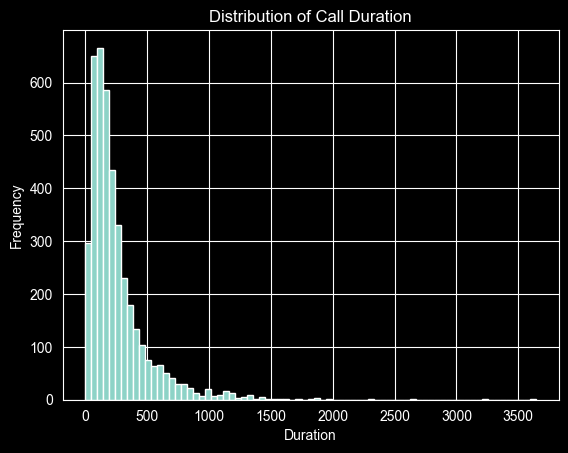

In [12]:
plt.figure()
plt.hist(df['duration'], bins=75)
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title('Distribution of Call Duration')
plt.show()

strongly right skewed

In [13]:
print(df.groupby('y')['duration'].mean())

y
0    219.40976
1    560.78714
Name: duration, dtype: float64


Seems relevant, but temporal leakage (session 4) do not use, availability at prediction time

### Previous

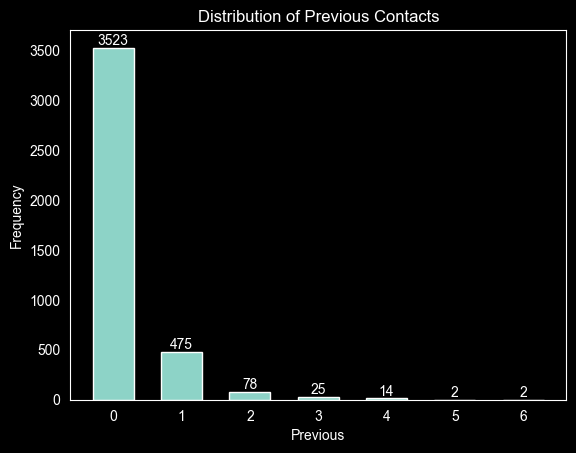

In [14]:
counts = df['previous'].value_counts().sort_index()
plt.figure()
bars = plt.bar(counts.index, counts.values, width=0.6)
plt.xlabel('Previous')
plt.ylabel('Frequency')
plt.title('Distribution of Previous Contacts')
plt.xticks(counts.index)
plt.grid(False)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )
plt.show()

extreme skewness

### Job

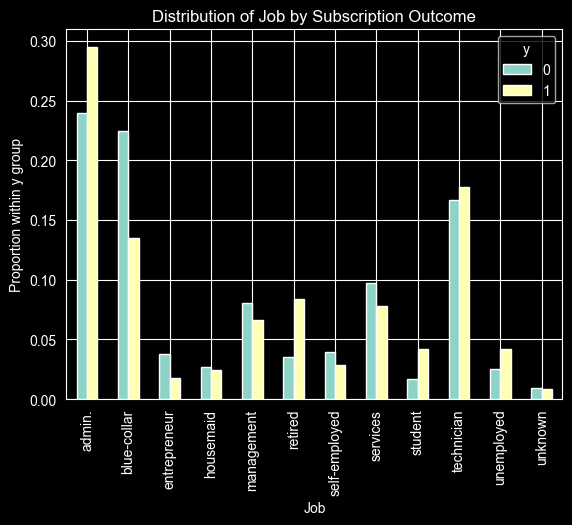

y                     0         1
job                              
admin.         0.239640  0.294900
blue-collar    0.224373  0.135255
entrepreneur   0.038168  0.017738
housemaid      0.026990  0.024390
management     0.080153  0.066519
retired        0.034896  0.084257
self-employed  0.039804  0.028825
services       0.097601  0.077605
student        0.017176  0.042129
technician     0.166576  0.177384
unemployed     0.025082  0.042129
unknown        0.009542  0.008869


In [18]:
pd.crosstab(df['job'], df['y'], normalize='columns').plot(kind='bar')
plt.ylabel("Proportion within y group")
plt.xlabel("Job")
plt.title("Distribution of Job by Subscription Outcome")
plt.show()

print(df.groupby(['job', 'y']).size().unstack().apply(lambda x: x / x.sum(), axis=0))

need stratification, due to class unbalance

### Education

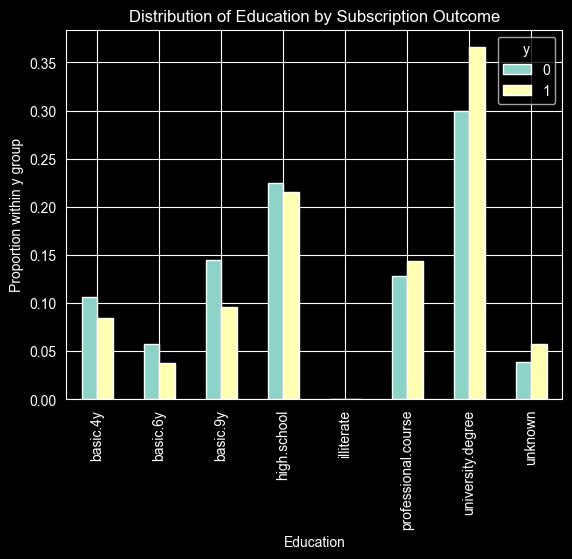

y                           0         1
education                              
basic.4y             0.106598  0.084257
basic.6y             0.057525  0.037694
basic.9y             0.144766  0.095344
high.school          0.224646  0.215078
illiterate           0.000273       NaN
professional.course  0.128135  0.144124
university.degree    0.299618  0.365854
unknown              0.038441  0.057650


In [20]:
pd.crosstab(df['education'], df['y'], normalize='columns').plot(kind='bar')
plt.title("Distribution of Education by Subscription Outcome")
plt.xlabel("Education")
plt.ylabel("Proportion within y group")
plt.show()

print(df.groupby(['education', 'y']).size().unstack().apply(lambda x: x / x.sum(), axis=0))

University Degree
- Higher proportion in y=1 than in y=0
- Suggests higher education is positively associated with subscription

Basic Education Levels (basic.4y, basic.6y, basic.9y)
- Slightly higher proportions in y=0
- Suggests lower education groups are less likely to subscribe

Professional Course
- Slightly higher in y=1

Unknown
- Slightly higher in y=1 (may require investigation)

need stratification, due to class unbalance

## 4. Data Splitting

## 5. Managing Missing Values


## 6. Encoding Categorical Variables


## 7. Feature Scaling


## 8. Addressing Class Imbalance


## 9. Feature Selection


## 10. Training a Logistic Regression Model


## 11. Model Evaluation

AI, for data visualization code